## Predicting Student Mental Health Score from Social Media Usage

We're predicting a student's `Mental_Health_Score` (a continuous score from ~3 to ~10) using their social media habits, study time, sleep, physical activity, and stress level. This is a **regression** problem since the target is a number, not a category.

**Dataset:** `Student_Social_Media_And_Mental_Health_Impact.csv` — 5,000 students, 13 columns covering demographics (Age, Gender, Country), platform usage (Avg_Daily_Usage_Hours, Daily_Unlocks, Most_Used_Platform), lifestyle (Study_Hours, Sleep_Hours_Per_Night, Physical_Activity_Hours), and Stress_Level.

### Import libraries — pandas, numpy, matplotlib/seaborn, scikit-learn, joblib

In [2]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

### Load the dataset and check shape & column names

In [3]:
df= pd.read_csv("Data.csv")
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [4]:
df.columns.to_list()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score']

In [5]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 5000
Columns: 13


In [6]:
for i,col in enumerate(df.columns):
    print(i+1,".",col, "---->", df[col].dtype)

1 . Age ----> int64
2 . Gender ----> str
3 . Country ----> str
4 . Academic_Level ----> str
5 . Most_Used_Platform ----> str
6 . Purpose_Of_Use ----> str
7 . Avg_Daily_Usage_Hours ----> float64
8 . Daily_Unlocks ----> int64
9 . Study_Hours ----> float64
10 . Physical_Activity_Hours ----> float64
11 . Sleep_Hours_Per_Night ----> float64
12 . Stress_Level ----> str
13 . Mental_Health_Score ----> float64


### Basic data understanding — data types, missing values, duplicate rows, summary statistics

### Besic INFO

In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 736.5 KB
None


### Null & Duplicate Check

In [8]:
print("Nulls:")
print("-----------------")
print(df.isna().sum())

print("")
print("Duplicates:")
print("-----------------")
print(df.duplicated().sum())

Nulls:
-----------------
Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

Duplicates:
-----------------
2


### StatisticalView

In [9]:
print("Catagorical Analysis: ")
df.select_dtypes(exclude= np.number).describe(include= "all")

Catagorical Analysis: 


,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Stress_Level
count,5000,5000,5000,5000,5000,5000
unique,2,111,3,12,4,4
top,Male,Other,Undergraduate,Instagram,Entertainment,Very High
freq,2635,1880,3632,1130,2552,1621


In [10]:
print("Numarical Analysis: ")
df.describe()

Numarical Analysis: 


,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


### Exploratory Data Analysis — target distribution, correlation heatmap, stress vs score, usage vs score, sleep vs score, platform counts

#### HistPlot And BoxPlot For More info about Data

In [11]:
sns.set_theme(context= "notebook", style= "darkgrid")

X features Plots:


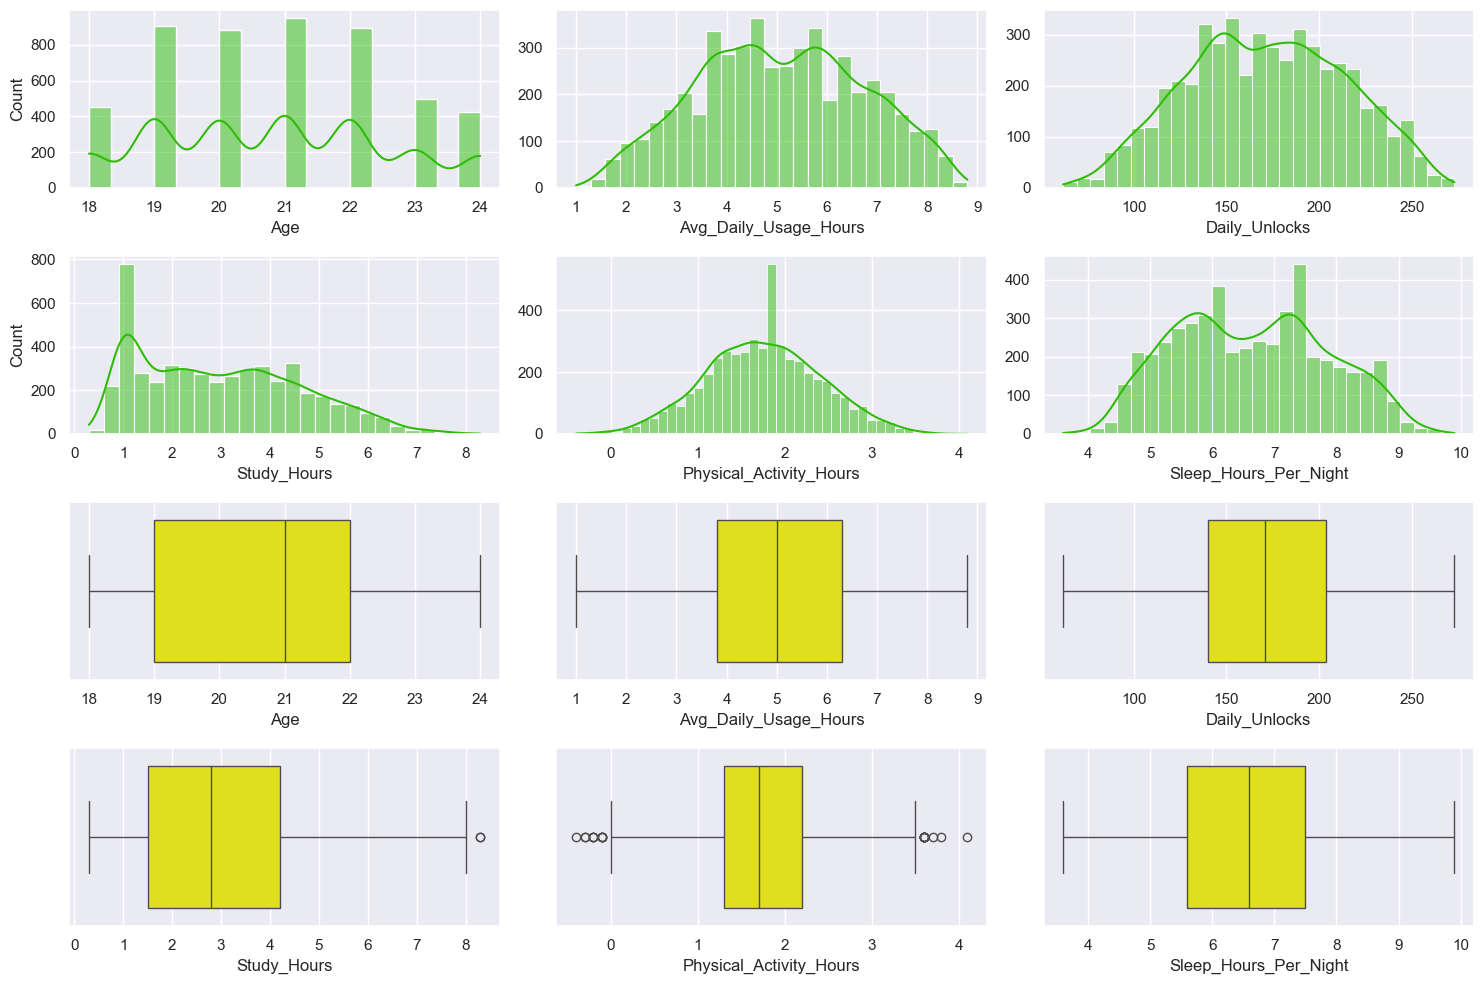

In [12]:
print("X features Plots:")
fig, axes= plt.subplots(2+2, 3, figsize= (15, 10))
axes= axes.flatten()
for i, col in enumerate([
    "Age", 
    "Avg_Daily_Usage_Hours", 
    "Daily_Unlocks", 
    "Study_Hours", 
    "Physical_Activity_Hours", 
    "Sleep_Hours_Per_Night"
    ]):
    sns.histplot(
        df[col],
        kde= True,
        color= "#2EBD07",
        ax= axes[i]
    )
    sns.boxplot(
        x= df[col],
        color= "yellow",
        ax= axes[i+6]
    )
    if i!= 0 and i!= 3:
        axes[i].set_ylabel("")
plt.tight_layout()

### Target Destribution Plots

<Axes: xlabel='Mental_Health_Score'>

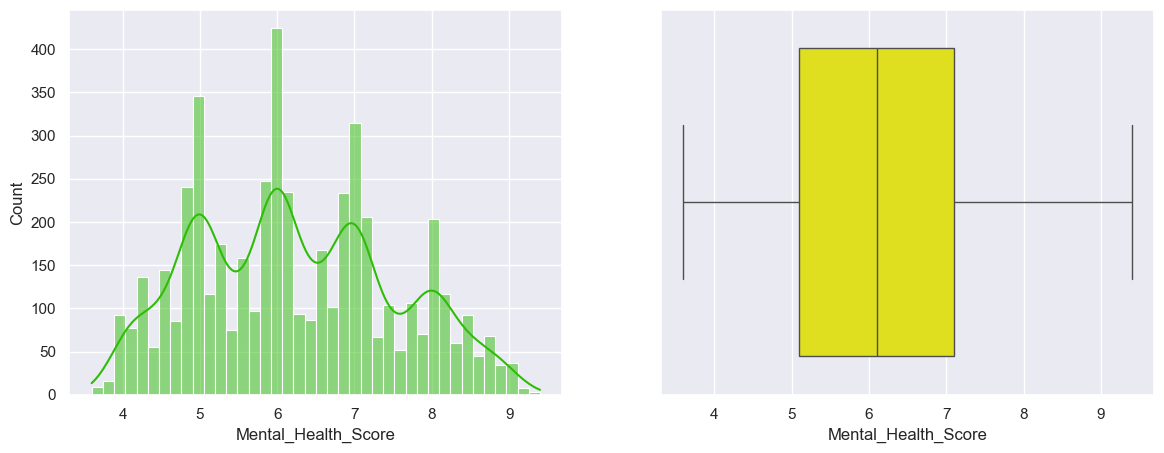

In [13]:
plt.figure(figsize= (14, 5))
plt.subplot(1, 2, 1)
sns.histplot(
    df["Mental_Health_Score"],
    bins= 40,
    kde= True,
    color= "#2EBD07"
)
plt.subplot(1, 2, 2)
sns.boxplot(
    x= df["Mental_Health_Score"],
    color= "yellow"
)

#### `MenterlHealthScore` VS `AvgDailyUsageHours` & `SleepHoursPerNigh`

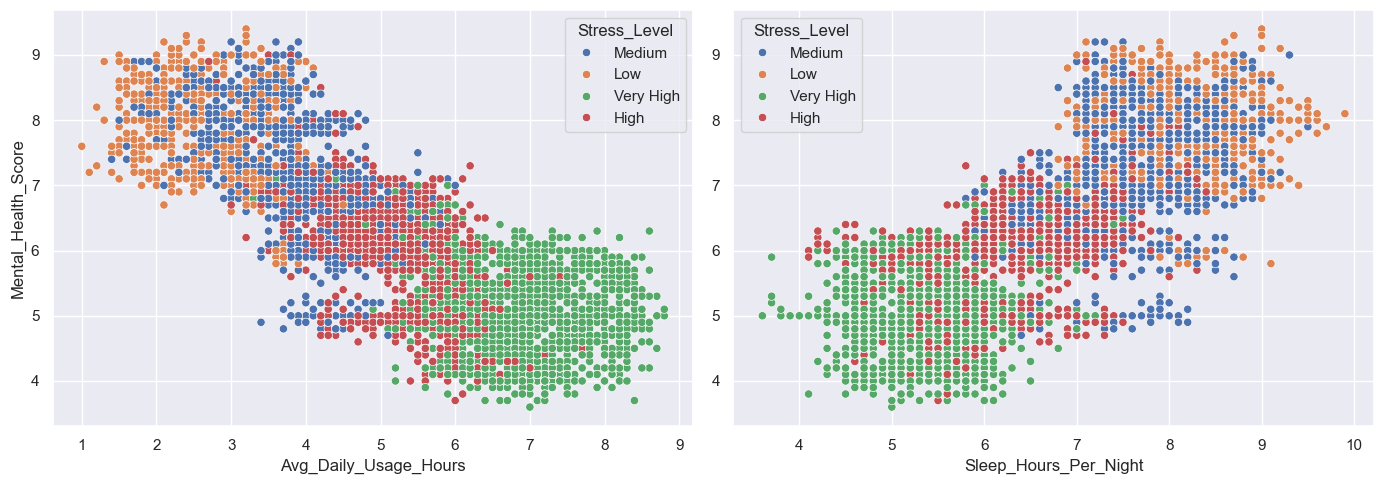

In [14]:
plt.figure(figsize= (14, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(
    y= df["Mental_Health_Score"],
    x= df["Avg_Daily_Usage_Hours"],
    hue= df["Stress_Level"]
)
plt.subplot(1, 2, 2)
sns.scatterplot(
    y= df["Mental_Health_Score"],
    x= df["Sleep_Hours_Per_Night"],
    hue= df["Stress_Level"]
)
plt.ylabel("")
plt.tight_layout()

#### `Stress_Level` VS `Mental_Health_Score` & `Study_Hours`

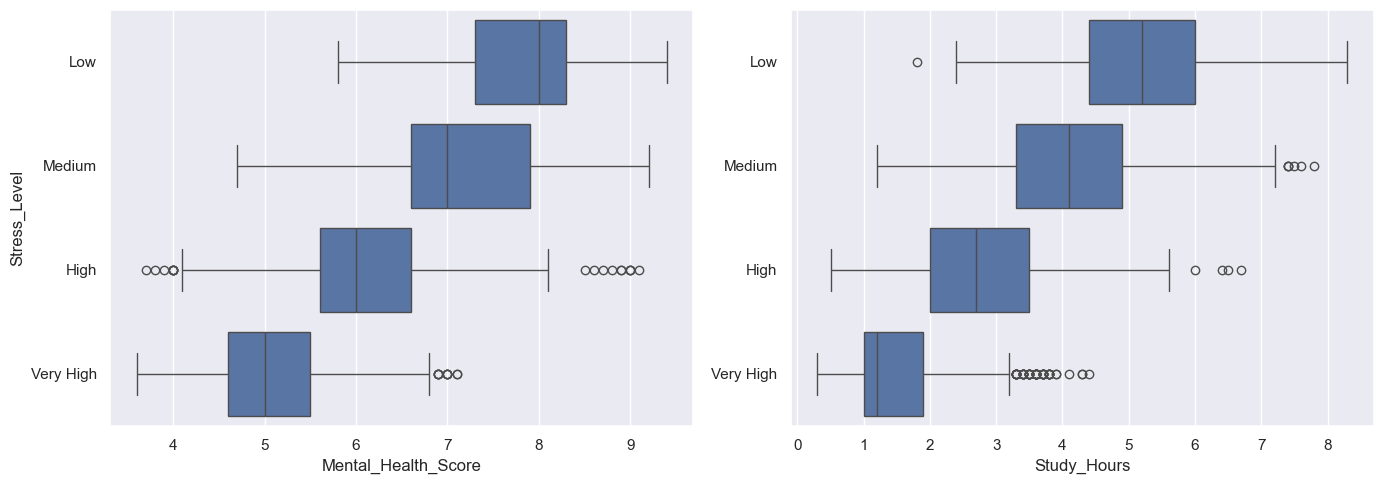

In [15]:
plt.figure(figsize= (14, 5))
plt.subplot(1, 2, 1)
sns.boxplot(
    y= df["Stress_Level"],
    x= df["Mental_Health_Score"],
    order= df["Stress_Level"].value_counts().sort_values().index
)
plt.subplot(1, 2, 2)
sns.boxplot(
    y= df["Stress_Level"],
    x= df["Study_Hours"],
    order= df["Stress_Level"].value_counts().sort_values().index
)
plt.ylabel("")
plt.tight_layout()
plt.show()

#### CountPlots

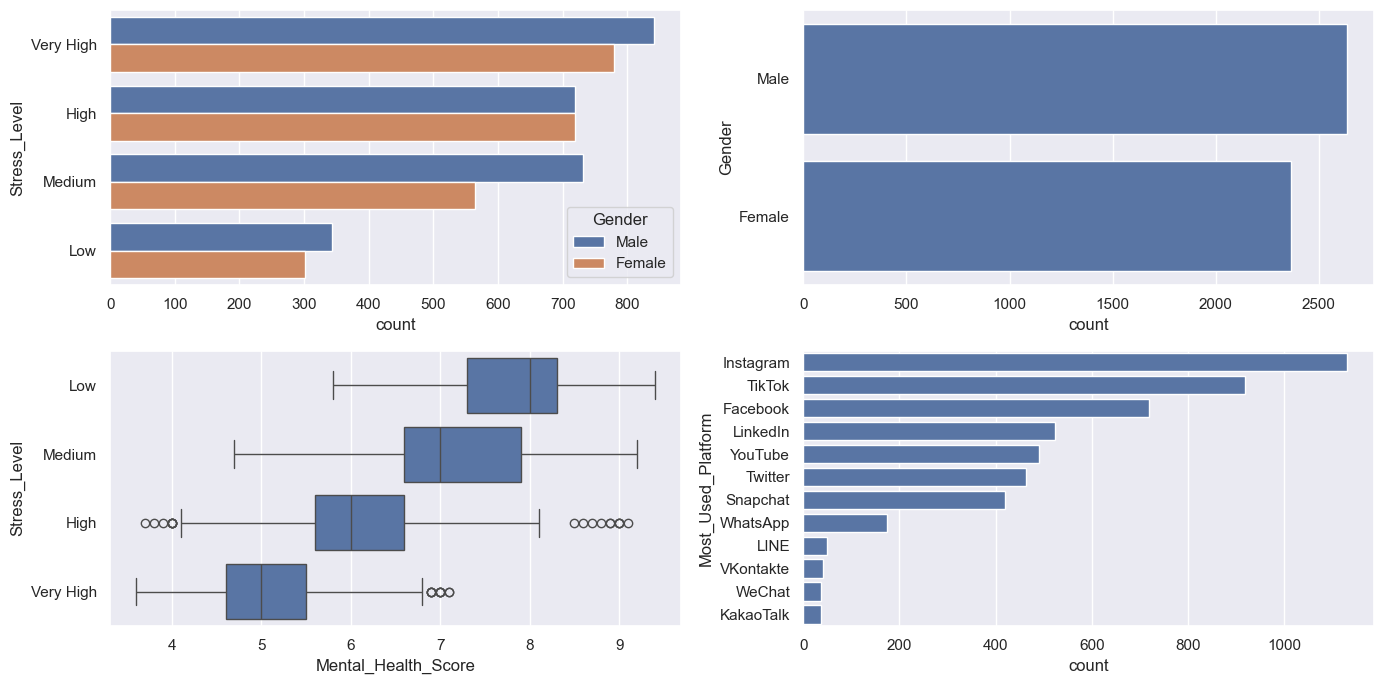

In [16]:
plt.figure(figsize= (14, 7))
plt.subplot(2, 2, 1)
sns.countplot(y= df["Stress_Level"], order= df["Stress_Level"].value_counts().index, hue= df["Gender"])
plt.subplot(2, 2, 2)
sns.countplot(df["Gender"])
plt.subplot(2, 2, 3)
sns.boxplot(y= df["Stress_Level"], x= df["Mental_Health_Score"], order= df["Stress_Level"].value_counts().index[::-1])
plt.subplot(2, 2, 4)
sns.countplot(df["Most_Used_Platform"], order= df["Most_Used_Platform"].value_counts().sort_values().index[::-1])
plt.tight_layout()

#### Corelations

In [17]:
corr= df.corr(numeric_only= True)
corr["Mental_Health_Score"]

Age                        0.100785
Avg_Daily_Usage_Hours     -0.816453
Daily_Unlocks             -0.790851
Study_Hours                0.752626
Physical_Activity_Hours    0.521374
Sleep_Hours_Per_Night      0.766430
Mental_Health_Score        1.000000
Name: Mental_Health_Score, dtype: float64

In [18]:
cat_cols= df.select_dtypes(exclude= np.number).columns
grand_mean= df["Mental_Health_Score"].mean()
ss_total= np.sum((df["Mental_Health_Score"]- grand_mean)** 2)
eta_score_dict= {"Feature": [], "Eta_Score": []}
for col in cat_cols.dropna().unique():
    ss_between= 0
    for cat in df[col].dropna().unique():
        sub_cat= df[df[col]== cat]["Mental_Health_Score"].dropna()
        cat_len= len(sub_cat)
        cat_mean= sub_cat.mean()
        
        ss_between+= cat_len* ((cat_mean- grand_mean)** 2)
    
    eta_score= ss_between/ ss_total
    eta_score_dict["Feature"].append(col)
    eta_score_dict["Eta_Score"].append(eta_score)
df_eta= pd.DataFrame(eta_score_dict)
df_eta

,Feature,Eta_Score
0,Gender,0.001146
1,Country,0.182166
2,Academic_Level,0.010308
3,Most_Used_Platform,0.046689
4,Purpose_Of_Use,0.008687
5,Stress_Level,0.617196


In [19]:
plt.figure(figsize= (18, 3+ 3+ 3), dpi= 600)
plt.subplot(3, 1, 1)
sns.heatmap(
    df.corr(numeric_only= True), 
    annot= True, 
    cmap= "RdBu", 
    linewidths= .01, 
    linecolor= "#000000",
    )
plt.xticks(rotation= 0)
plt.subplot(3, 1, 2)
sns.barplot(
    x= corr["Mental_Health_Score"], 
    y= corr.columns, 
    order= corr["Mental_Health_Score"].sort_values().index,
    palette='RdBu'
    )
plt.axvline(0, color='grey', linestyle='--')

plt.subplot(3, 1, 3)
ax = sns.barplot(data=df_eta, x='Eta_Score', y='Feature', palette='viridis', order= df_eta.sort_values(["Eta_Score"], ascending= False)["Feature"])
plt.title(
    'Categorical Features Correlation with Target (Eta-Squared)',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Eta Score (Correlation Ratio)', fontsize=10)
plt.ylabel('Categorical Features', fontsize=10)
plt.xlim(0, 0.7)  # Zoom scale
for index, value in enumerate(df_eta['Eta_Score'].sort_values(ascending= False)):
    ax.text(value + 0.01, index, f'{value:.4f}', va='center', fontweight='bold')
plt.tight_layout()


### Data cleaning — drop duplicate rows, fix an invalid negative value found in the data

In [20]:
df["Physical_Activity_Hours"]= df["Physical_Activity_Hours"].clip(lower= 0)

In [21]:
df.drop_duplicates(inplace= True)

### Check skewness on numeric columns, log-transform the one column that needed it

Study_Hours                0.436125
Mental_Health_Score        0.207086
Age                        0.155008
Sleep_Hours_Per_Night      0.123919
Physical_Activity_Hours    0.053288
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
dtype: float64


Text(0, 0.5, 'Features')

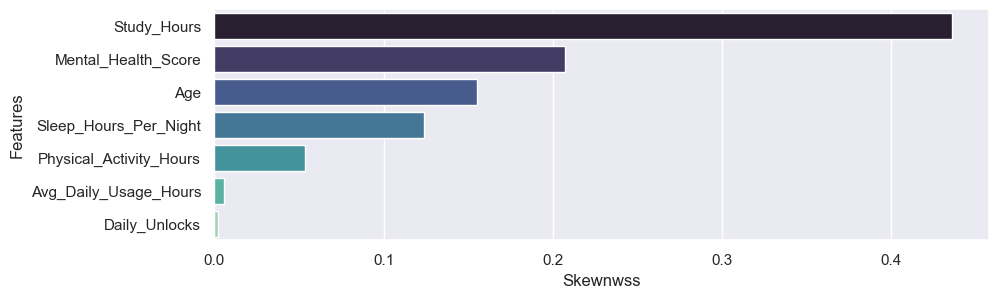

In [22]:
plt.figure(figsize= (10, 3))
skew= df.select_dtypes(include= np.number).skew()
print(skew.sort_values(ascending= False))
sns.barplot(x= skew, y= skew.index, order= skew.sort_values(ascending= False).index, palette= "mako")
plt.xlabel("Skewnwss")
plt.ylabel("Features")

In [23]:
num_fet= df.select_dtypes(include= np.number)
q1= num_fet.quantile(.25)
q3= num_fet.quantile(.75)
iqr= q3- q1

lower_fence= q1- 1.5* iqr 
upper_fence= q3+ 1.5* iqr 

outliers= (lower_fence> num_fet) | (upper_fence< num_fet)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    12
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


##### we alrady saw in BoxPlot 

In [24]:
for col in df.select_dtypes(include= np.number).columns.to_list():
    Q1= df[col].quantile(.25)
    Q3= df[col].quantile(.75)
    IQR= Q3- Q1
    
    lower_bound= Q1- 1.5* IQR
    upper_bound= Q3+ 1.5* IQR
    
    outlier= (df[col]> upper_bound)| (df[col]< lower_bound)
    if outlier.sum()!=  0:
        display(df[outlier])     
        print(f"{len(df[outlier])} Outliers found in {col} Column")
        print("")


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2948,23,Female,Other,Graduate,LinkedIn,Education,1.8,107,8.3,2.5,8.0,Low,7.4
4589,23,Female,Other,Graduate,LinkedIn,Education,1.7,107,8.3,2.5,7.9,Low,7.5


2 Outliers found in Study_Hours Column



,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
934,22,Female,Other,Undergraduate,TikTok,Entertainment,2.3,93,5.8,3.6,8.0,Low,8.5
1784,22,Male,Afghanistan,Undergraduate,LinkedIn,Education,2.9,132,4.2,3.6,7.0,Medium,7.0
2082,21,Male,India,Undergraduate,Instagram,Entertainment,3.3,136,5.9,3.6,6.9,Medium,7.2
2512,24,Female,Other,Graduate,Instagram,Entertainment,2.1,103,7.2,3.6,8.1,Low,8.7
2549,22,Male,Afghanistan,Undergraduate,LinkedIn,Education,2.6,132,4.2,3.6,6.8,Medium,7.1
3051,22,Male,Japan,Undergraduate,Twitter,News,4.6,149,3.1,3.7,7.4,Medium,8.0
3620,22,Male,Afghanistan,Undergraduate,LinkedIn,Education,3.2,132,4.3,4.1,7.0,Medium,6.7
3988,18,Male,Other,High School,Twitter,News,1.6,98,5.9,3.6,7.7,Low,8.0
4187,21,Female,India,Undergraduate,YouTube,Education,3.0,94,5.9,3.8,7.3,Low,7.1
4580,22,Male,Afghanistan,Undergraduate,LinkedIn,Education,3.1,132,4.2,3.6,7.3,Medium,7.3


12 Outliers found in Physical_Activity_Hours Column



### Feature engineering — group a high-cardinality column into top categories + "Other"

In [25]:
countris= df["Country"].value_counts().sort_values(ascending= False)[:12]

In [26]:
countris.index

Index(['Other', 'India', 'USA', 'Canada', 'Australia', 'UK', 'Germany',
       'Mexico', 'Turkey', 'France', 'Spain', 'Ireland'],
      dtype='str', name='Country')

In [27]:
def cnt(c_name) -> list:
    if c_name in countris.index:
        return c_name
    else:
        return "Other"

In [28]:
df["Groupd_contry"]= df["Country"].apply(lambda c: c if c in countris.index else "Other")

In [29]:
df.drop("Country", axis= 1, inplace= True)

In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 4998 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4998 non-null   int64  
 1   Gender                   4998 non-null   str    
 2   Academic_Level           4998 non-null   str    
 3   Most_Used_Platform       4998 non-null   str    
 4   Purpose_Of_Use           4998 non-null   str    
 5   Avg_Daily_Usage_Hours    4998 non-null   float64
 6   Daily_Unlocks            4998 non-null   int64  
 7   Study_Hours              4998 non-null   float64
 8   Physical_Activity_Hours  4998 non-null   float64
 9   Sleep_Hours_Per_Night    4998 non-null   float64
 10  Stress_Level             4998 non-null   str    
 11  Mental_Health_Score      4998 non-null   float64
 12  Groupd_contry            4998 non-null   str    
dtypes: float64(5), int64(2), str(6)
memory usage: 775.3 KB


#### Decide encoding strategy — ordinal for ordered categories, one-hot for unordered ones

1. Academic_Level --> OrdenlaEncodeing: Because  `High School`< `Undergraduate`< `Graduate`
2. Stress_Level --> OrdenlaEncodeing: Because  `Low`< `Medium`< `High`< `Very High`
3. Gender --> OneHot
4. Most_Used_Platform --> OneHot
5. Purpose_Of_Use --> OneHot
6. Groupd_contry --> OneHot

#### Train/test split, done before any preprocessing to avoid data leakage

In [31]:
from sklearn.model_selection import train_test_split, KFold

X= df.drop(columns= ["Mental_Health_Score"])
y= df["Mental_Health_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= .2, random_state= 42)

skewd_col= ['Study_Hours']        
ordenal_col= ["Academic_Level", "Stress_Level"]
onehot_col= ["Gender", "Most_Used_Platform", "Purpose_Of_Use", "Groupd_contry"]   
scaleing_col= ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']

#### Build preprocessing with ColumnTransformer — impute, scale, encode

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

skew_pipe= Pipeline(
    [
        ("Impute", SimpleImputer(strategy= "median")),
        ("Log_Transformation", FunctionTransformer(np.log1p)),
        ("Scale", StandardScaler())
    ] 
)
ordenal_pipe= Pipeline(
    [
        ("Impute", SimpleImputer(strategy= "most_frequent")),
        ("Ord_Encode", OrdinalEncoder(categories= [['High School', 'Undergraduate', 'Graduate'], ['Low', 'Medium', 'High', 'Very High']])),
    ]
)
onehot_pipe= Pipeline(
    [
        ("Impute", SimpleImputer(strategy= "most_frequent")),
        ("OH_encode", OneHotEncoder(handle_unknown= "ignore"))
    ]
)
scale_pipe= Pipeline(
    [
        ("impute", SimpleImputer(strategy= "median")),
        ("Scale", StandardScaler())
    ]
)
compose= ColumnTransformer(
    [
        ("skewd", skew_pipe, skewd_col),
        ("ordenal_encode", ordenal_pipe, ordenal_col),
        ("onehot_encode", onehot_pipe, onehot_col),
        ("Scale", scale_pipe, scaleing_col)
    ],
    remainder= "passthrough"
)
main_pipe= Pipeline(
    [
        ("Process", compose),
        ("model", LinearRegression())
    ]
)

In [33]:
main_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Process', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewd', ...), ('ordenal_encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [34]:
y_pred_base= main_pipe.predict(X_test)
y_pred_base_train= main_pipe.predict(X_train)

In [35]:
rf_pipe= Pipeline(
    [
        ("Process", compose),
        ("model", RandomForestRegressor(
            n_estimators= 120,
            criterion= "poisson",
            max_depth= 5,
        ))
    ]
)
rf_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Process', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewd', ...), ('ordenal_encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [36]:
y_pred_rf= rf_pipe.predict(X_test)
y_pred_rf_train= rf_pipe.predict(X_train)

In [37]:
base_model= [
    ("lr", LinearRegression()),
    ("KNN", KNeighborsRegressor(n_neighbors= 5, weights= "distance")),
    ("GBR", GradientBoostingRegressor(n_estimators= 120, random_state= 42)),
    ("RFR", RandomForestRegressor(n_estimators= 120, criterion= "squared_error"))
]

meta_model= Ridge(alpha= 1.2)

stacking= StackingRegressor(
    estimators= base_model,
    final_estimator= meta_model,
    cv= KFold(n_splits= 5, shuffle= True, random_state= 42)
)

In [38]:
stack_pipe= Pipeline(
    [
        ("Process", compose),
        ("model", stacking)
    ]
)

In [39]:
stack_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Process', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewd', ...), ('ordenal_encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [40]:
from IPython.display import display, HTML

# Pipeline ka raw HTML string generate hoga
html_code = stack_pipe._repr_html_()

# Isko print kar ya file me save kar le
with open("pipeline_diagram.html", "w", encoding="utf-8") as f:
    f.write(html_code)

In [41]:
y_pred_stack= stack_pipe.predict(X_test)
y_pred_stack_train= stack_pipe.predict(X_train)

In [42]:
def scores(pipeline, X_data, y_true, y_pred, train_or_test, model_name):
    
    r2= r2_score(y_true, y_pred)
    n= len(X_data)
    p= pipeline.named_steps["Process"].transform(X_data).shape[1]
    adjr2= 1- ((1- r2)* (n-1)/ (n- p- 1))
    
    mse= mean_squared_error(y_true, y_pred)
    mae= mean_absolute_error(y_true, y_pred)
    
    return pd.DataFrame([r2, adjr2, mse, mae], index= ["R Squre", "Adjusted R Squre", "MeanSquaredError", "MeanAbsoluteError"], columns= [train_or_test+ " "+ model_name])

In [43]:
result_table= pd.concat(
    [
        scores(
            main_pipe,
            X_train,
            y_train, 
            y_pred_base_train, 
            "Train",
            "LR"
        ),
        scores(
            main_pipe,
            X_test,
            y_test,
            y_pred_base,
            "Test",
            "LR"
        ),
        scores(
            rf_pipe,
            X_train,
            y_train,
            y_pred_rf_train,
            "Train",
            "RF"
        ),
        scores(
            rf_pipe,
            X_test,
            y_test,
            y_pred_rf,
            "Test",
            "RF"
        ),
        scores(
            stack_pipe,
            X_train,
            y_train,
            y_pred_stack_train,
            "Train",
            "Stacking"
        ),
        scores(
            stack_pipe,
            X_test,
            y_test,
            y_pred_stack,
            "Test",
            "Stacking"
        )
    ], axis= 1)

In [44]:
result_table

,Train LR,Test LR,Train RF,Test RF,Train Stacking,Test Stacking
R Squre,0.730319,0.745427,0.795237,0.790441,0.993910,0.919042
Adjusted R Squre,0.727730,0.735360,0.793271,0.782154,0.993851,0.915841
MeanSquaredError,0.430461,0.454466,0.326840,0.374107,0.009721,0.144526
MeanAbsoluteError,0.514401,0.529695,0.443118,0.474185,0.075057,0.262311


In [45]:
sns.set_theme(style= "darkgrid", context= "notebook")

In [46]:
result_table.loc[['R Squre', 'Adjusted R Squre']].T.reset_index()

,index,R Squre,Adjusted R Squre
0,Train LR,0.730319,0.727730
1,Test LR,0.745427,0.735360
2,Train RF,0.795237,0.793271
3,Test RF,0.790441,0.782154
4,Train Stacking,0.993910,0.993851
5,Test Stacking,0.919042,0.915841


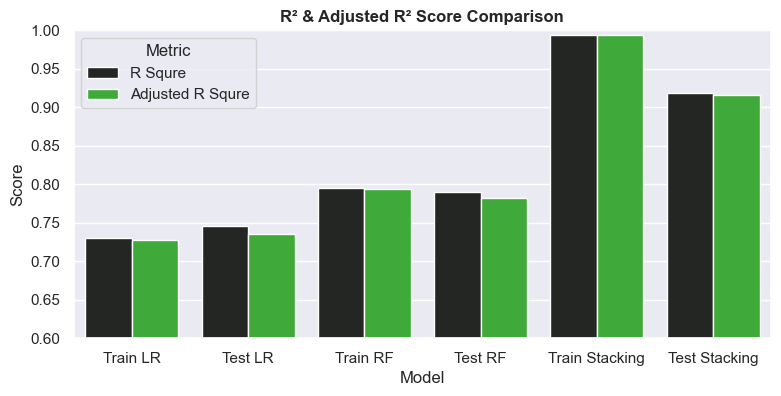

In [47]:

df_r2 = result_table.loc[['R Squre', 'Adjusted R Squre']].T.reset_index()
df_r2_melted = df_r2.melt(
    id_vars='index', var_name='Metric', value_name='Score'
)

plt.figure(figsize=(9, 4))
sns.barplot(
    data=df_r2_melted,
    x='index',
    y='Score',
    hue='Metric',
    color= "#2EBC26"
)

plt.title('R² & Adjusted R² Score Comparison', fontsize=12, fontweight='bold')
plt.xlabel('Model')
plt.ylim(0.6, 1.0)
plt.show()

In [48]:
result_table

,Train LR,Test LR,Train RF,Test RF,Train Stacking,Test Stacking
R Squre,0.730319,0.745427,0.795237,0.790441,0.993910,0.919042
Adjusted R Squre,0.727730,0.735360,0.793271,0.782154,0.993851,0.915841
MeanSquaredError,0.430461,0.454466,0.326840,0.374107,0.009721,0.144526
MeanAbsoluteError,0.514401,0.529695,0.443118,0.474185,0.075057,0.262311


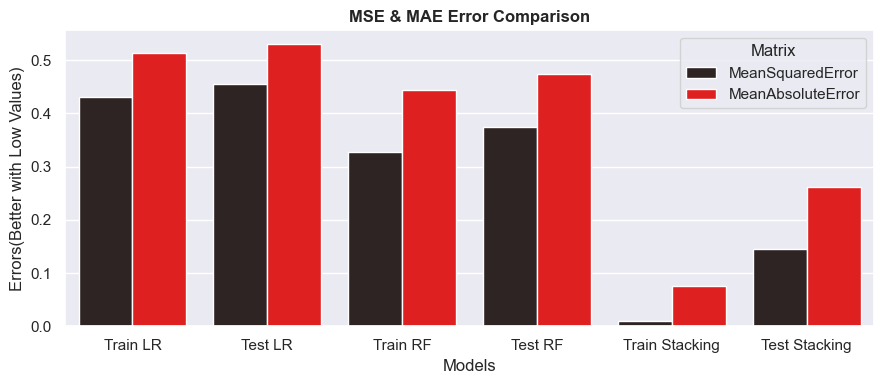

In [49]:
error= result_table.loc[["MeanSquaredError", "MeanAbsoluteError"]].T.reset_index()
plt.figure(figsize=(9, 4))
error_melted= error.melt(id_vars= "index", var_name= "Matrix",value_name= "Errors")
sns.barplot(
    data= error_melted,
    x= "index",
    y= "Errors",
    hue= "Matrix",
    # palette= "Reds_r",
    color= "red"
)
plt.ylabel("Errors(Better with Low Values)")
plt.xlabel("Models")
plt.ylim()
plt.xticks()
plt.title('MSE & MAE Error Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [50]:
cat_cols= df.select_dtypes(exclude= np.number).columns

In [51]:
from scipy.stats import stats
hypothesis= {
    "Feature": [],  
    "Test": [],
    "Test_Score": [],
    "P-Value": [],
    "Disition": []
} 
for i in cat_cols:
    val= []
    for j in df[i].value_counts().index:
        value= df[df[i]== j]["Mental_Health_Score"].dropna()
        val.append(value)        
    num_groups= len(val)

    if num_groups== 2:
        t_score, p_val= stats.ttest_ind(val[0], val[1])
        print(f'Feature: {i} | Welch t-test -> t-stat: {t_score:.4f}, p-val: {p_val:.6f}')
        hypothesis["Feature"].append(i)
        hypothesis["Test"].append("T-Test")
        hypothesis["Test_Score"].append(round(t_score, 4))
        hypothesis["P-Value"].append(round(p_val, 6))
        decision = (
            "Reject Null Hypothesis" if p_val < 0.05 else "Fail to Reject H0"
        )
        hypothesis["Disition"].append(decision)

    elif num_groups > 2:
        stat, p_val = stats.f_oneway(*val)
        print(f'Feature: {i} | One-Way ANOVA -> F-stat: {stat:.4f}, p-val: {p_val:.6f}')
        hypothesis["Feature"].append(i)
        hypothesis["Test"].append("Anova-Test")
        hypothesis["Test_Score"].append(round(stat, 4))
        hypothesis["P-Value"].append(round(p_val, 6))
        hypothesis["Disition"].append(decision)


Feature: Gender | Welch t-test -> t-stat: 2.3577, p-val: 0.018427
Feature: Academic_Level | One-Way ANOVA -> F-stat: 26.0339, p-val: 0.000000
Feature: Most_Used_Platform | One-Way ANOVA -> F-stat: 22.3045, p-val: 0.000000
Feature: Purpose_Of_Use | One-Way ANOVA -> F-stat: 14.7707, p-val: 0.000000
Feature: Stress_Level | One-Way ANOVA -> F-stat: 2685.9888, p-val: 0.000000
Feature: Groupd_contry | One-Way ANOVA -> F-stat: 18.3267, p-val: 0.000000


In [52]:
hypothesis= pd.DataFrame(hypothesis)

In [54]:
hypothesis

,Feature,Test,Test_Score,P-Value,Disition
0,Gender,T-Test,2.3577,0.018427,Reject Null Hypothesis
1,Academic_Level,Anova-Test,26.0339,0.000000,Reject Null Hypothesis
2,Most_Used_Platform,Anova-Test,22.3045,0.000000,Reject Null Hypothesis
3,Purpose_Of_Use,Anova-Test,14.7707,0.000000,Reject Null Hypothesis
4,Stress_Level,Anova-Test,2685.9888,0.000000,Reject Null Hypothesis
5,Groupd_contry,Anova-Test,18.3267,0.000000,Reject Null Hypothesis


In [ ]:
import joblib
# joblib.dump(stack_pipe, "Stacking_pipeline.pkl")

In [ ]:
df["Stress_Level"].unique()

<ArrowStringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str

In [ ]:
print("Radha")

Radha
